<a href="https://colab.research.google.com/github/abhishek22112001/Ai-finalproject/blob/main/robotic_software_programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Install PyBullet ---
!pip install pybullet

# --- Imports ---
import pybullet as p
import pybullet_data
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

In [ ]:
# --- Setup PyBullet Environment in DIRECT mode ---
p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.8)

In [ ]:
# --- Create URDFs ---
urdf_dir = "urdfs"
os.makedirs(urdf_dir, exist_ok=True)

def write_urdf(filename, content):
    with open(os.path.join(urdf_dir, filename), "w") as f:
        f.write(content)

write_urdf("box_table.urdf", """
<robot name="box_table">
  <link name="box_link">
    <visual>
      <geometry><box size="1 1 0.5"/></geometry>
      <origin xyz="0 0 0.25"/>
      <material name="grey"><color rgba="0.6 0.6 0.6 1"/></material>
    </visual>
    <collision>
      <geometry><box size="1 1 0.5"/></geometry>
      <origin xyz="0 0 0.25"/>
    </collision>
    <inertial>
      <mass value="1"/>
      <inertia ixx="0.1" iyy="0.1" izz="0.1" ixy="0" ixz="0" iyz="0"/>
    </inertial>
  </link>
</robot>
""")

write_urdf("cylinder_pillar.urdf", """
<robot name="cylinder_pillar">
  <link name="cylinder_link">
    <visual>
      <geometry><cylinder radius="0.2" length="1"/></geometry>
      <origin xyz="0 0 0.5"/>
      <material name="blue"><color rgba="0.1 0.1 0.8 1"/></material>
    </visual>
    <collision>
      <geometry><cylinder radius="0.2" length="1"/></geometry>
      <origin xyz="0 0 0.5"/>
    </collision>
    <inertial>
      <mass value="1"/>
      <inertia ixx="0.05" iyy="0.05" izz="0.05" ixy="0" ixz="0" iyz="0"/>
    </inertial>
  </link>
</robot>
""")

write_urdf("wall.urdf", """
<robot name="wall">
  <link name="wall_link">
    <visual>
      <geometry><box size="2 0.1 1"/></geometry>
      <origin xyz="0 0 0.5"/>
      <material name="dark"><color rgba="0.2 0.2 0.2 1"/></material>
    </visual>
    <collision>
      <geometry><box size="2 0.1 1"/></geometry>
      <origin xyz="0 0 0.5"/>
    </collision>
    <inertial>
      <mass value="1"/>
      <inertia ixx="0.2" iyy="0.2" izz="0.2" ixy="0" ixz="0" iyz="0"/>
    </inertial>
  </link>
</robot>
""")

write_urdf("block.urdf", """
<robot name="block">
  <link name="block_link">
    <visual>
      <geometry><box size="0.5 0.5 0.5"/></geometry>
      <origin xyz="0 0 0.25"/>
      <material name="red"><color rgba="0.8 0.2 0.2 1"/></material>
    </visual>
    <collision>
      <geometry><box size="0.5 0.5 0.5"/></geometry>
      <origin xyz="0 0 0.25"/>
    </collision>
    <inertial>
      <mass value="1"/>
      <inertia ixx="0.05" iyy="0.05" izz="0.05" ixy="0" ixz="0" iyz="0"/>
    </inertial>
  </link>
</robot>
""")

In [ ]:
# --- Load Plane and Objects ---
p.loadURDF("plane.urdf")

objects = [
    ("box_table.urdf", [0, 0, 0]),
    ("cylinder_pillar.urdf", [2, 2, 0]),
    ("wall.urdf", [-1, 2, 0]),
    ("block.urdf", [1, -1, 0]),
    ("block.urdf", [-2, -2, 0]),
    ("cylinder_pillar.urdf", [-1, -1, 0]),
    ("wall.urdf", [2, -2, 0]),
]

for obj_name, pos in objects:
    p.loadURDF(os.path.join(urdf_dir, obj_name), basePosition=pos)


In [ ]:
# --- Render from 3 Camera Angles ---
def capture_view(camera_pos, target, up_vector=[0, 0, 1]):
    view = p.computeViewMatrix(cameraEyePosition=camera_pos,
                                cameraTargetPosition=target,
                                cameraUpVector=up_vector)
    proj = p.computeProjectionMatrixFOV(fov=60, aspect=1.0,
                                        nearVal=0.1, farVal=100)
    _, _, px, _, _ = p.getCameraImage(512, 512, view, proj)
    return np.reshape(px, (512, 512, 4))[:, :, :3]

camera_views = [
    ([5, 5, 3], [0, 0, 0]),
    ([0, -7, 3], [0, 0, 0]),
    ([-7, 0, 3], [0, 0, 0])
]

images = [capture_view(pos, target) for pos, target in camera_views]


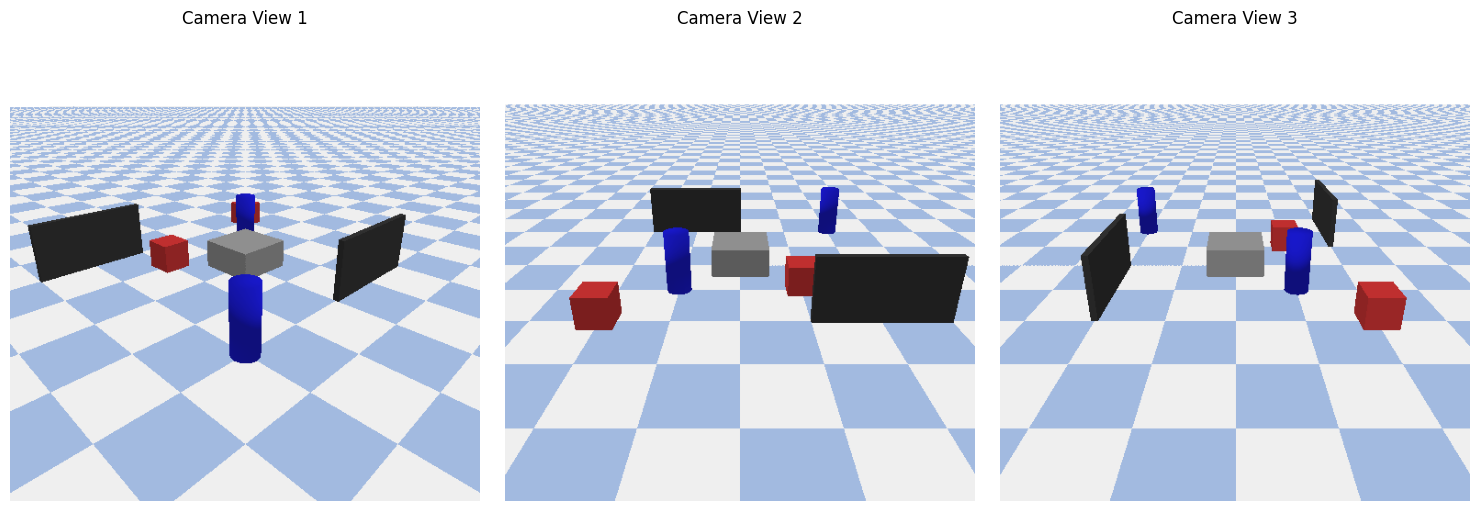

In [ ]:
#diplay the camera views using matplotlip

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(images[0])
axes[0].set_title("Camera View 1")
axes[0].axis('off')

axes[1].imshow(images[1])
axes[1].set_title("Camera View 2")
axes[1].axis('off')

axes[2].imshow(images[2])
axes[2].set_title("Camera View 3")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Disconnect after rendering
p.disconnect()